# 5G Signal Model Validation
Validates FSPL model, building attenuation, and coverage scoring against the population grid.

In [1]:
import sys, os

notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.abspath(os.path.join(notebook_dir, '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data_pipeline.signal.propagation import SignalModel, haversine
from data_pipeline.signal.coverage_scorer import CoverageScorer

plt.rcParams['figure.figsize'] = (12, 4)
print('Imports OK ✔')

Imports OK ✔


## 1. Load grid

In [2]:
grid_path = os.path.join(project_root, 'data_pipeline', 'processed', 'peshawar_grid.pkl')

with open(grid_path, 'rb') as f:
    grid = pickle.load(f)

print(f'Grid loaded : {grid.total_cells} cells')
print(f'Population  : {grid.total_population:,}')
print(f'Resolution  : {grid.resolution_m}m')
print(f'Bounds      : {grid.bounds}')

Grid loaded : 2120 cells
Population  : 7,989,208
Resolution  : 200.0m
Bounds      : {'lat_min': 33.928186, 'lat_max': 34.072891, 'lng_min': 71.433528, 'lng_max': 71.644018}


## 2. FSPL sanity check — signal decay with distance

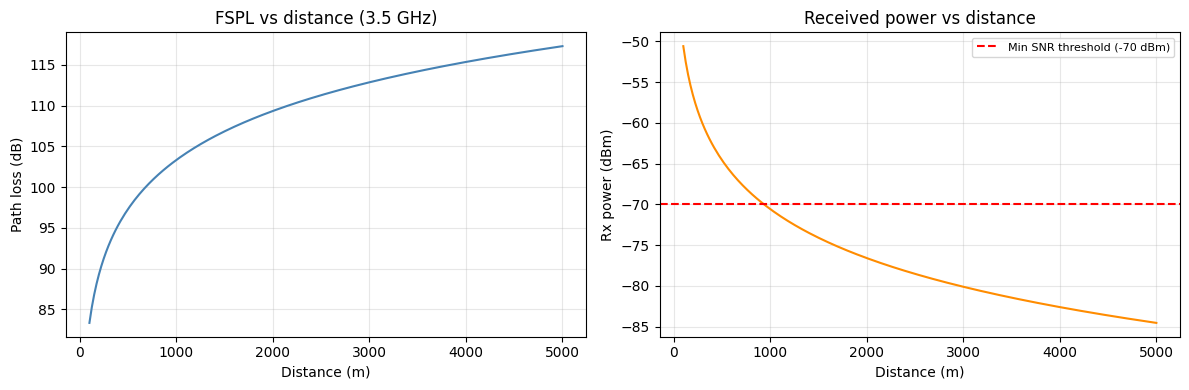

FSPL at 100m  : 83.3 dB
FSPL at 1000m : 103.3 dB
Difference    : 20.0 dB (expect ~20 dB) ✔


In [3]:
model = SignalModel(frequency_ghz=3.5)

distances = np.linspace(100, 5000, 200)
fspl_vals = [model.free_space_path_loss(d) for d in distances]
rx_power  = [model.calculate_received_power(
    tx_power_dbm=30, tx_height_m=30,
    rx_lat=34.015, rx_lng=71.525,
    tower_lat=34.015 + d / 111000, tower_lng=71.525,
    building_density=0.0
) for d in distances]

fig, axes = plt.subplots(1, 2)

axes[0].plot(distances, fspl_vals, color='steelblue')
axes[0].set_title('FSPL vs distance (3.5 GHz)')
axes[0].set_xlabel('Distance (m)')
axes[0].set_ylabel('Path loss (dB)')
axes[0].grid(alpha=0.3)

axes[1].plot(distances, rx_power, color='darkorange')
axes[1].axhline(-70, color='red', linestyle='--', label='Min SNR threshold (-70 dBm)')
axes[1].set_title('Received power vs distance')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('Rx power (dBm)')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Sanity: FSPL should increase ~20dB per decade
fspl_100  = model.free_space_path_loss(100)
fspl_1000 = model.free_space_path_loss(1000)
print(f'FSPL at 100m  : {fspl_100:.1f} dB')
print(f'FSPL at 1000m : {fspl_1000:.1f} dB')
print(f'Difference    : {fspl_1000 - fspl_100:.1f} dB (expect ~20 dB) ✔' if abs((fspl_1000-fspl_100)-20) < 1 else 'WARNING: unexpected difference')

## 3. Building attenuation effect

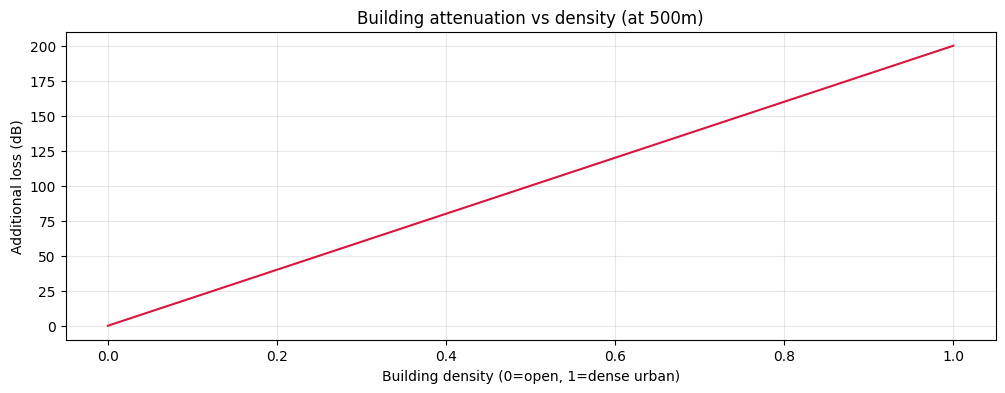

In [4]:
densities = np.linspace(0, 1, 50)
att_vals  = [model.building_attenuation(500, d) for d in densities]

plt.plot(densities, att_vals, color='crimson')
plt.title('Building attenuation vs density (at 500m)')
plt.xlabel('Building density (0=open, 1=dense urban)')
plt.ylabel('Additional loss (dB)')
plt.grid(alpha=0.3)
plt.show()

## 4. Single tower coverage

In [5]:
scorer = CoverageScorer(model, min_snr_db=-70)

mid = len(grid.cells) // 2
tower = {
    'lat': grid.cells[mid][0],
    'lng': grid.cells[mid][1],
    'height_m': 30,
    'power_dbm': 30,
}

result = scorer.calculate_tower_coverage(tower, grid)
print(f'Covered population : {result["covered_population"]:,}')
print(f'Coverage %         : {result["coverage_percent"]:.2f}%')
print(f'Avg SNR            : {result["avg_snr_db"]:.2f} dB')
print(f'Coverage radius    : {result["coverage_radius_m"]:.0f} m')

Covered population : 7,662,168
Coverage %         : 95.91%
Avg SNR            : -0.71 dB
Coverage radius    : 13210 m


## 5. Multi-tower coverage + interference

In [6]:
towers = [
    {'lat': grid.cells[0][0],   'lng': grid.cells[0][1],   'height_m': 30, 'power_dbm': 30},
    {'lat': grid.cells[mid][0], 'lng': grid.cells[mid][1], 'height_m': 30, 'power_dbm': 30},
    {'lat': grid.cells[-1][0],  'lng': grid.cells[-1][1],  'height_m': 30, 'power_dbm': 30},
]

total = scorer.calculate_total_coverage(towers, grid)
print(f'Total covered pop  : {total["total_covered_population"]:,}')
print(f'Coverage %         : {total["coverage_percent"]:.2f}%')
print(f'Avg SNR            : {total["avg_snr_db"]:.2f} dB')
print(f'Overlap %          : {total["overlap_percent"]:.2f}%')
print(f'Interference score : {total["interference_score"]:.2f} dB')

Total covered pop  : 7,680,976
Coverage %         : 96.14%
Avg SNR            : 2.88 dB
Overlap %          : 90.99%
Interference score : 8.18 dB


## 6. SNR map visualization

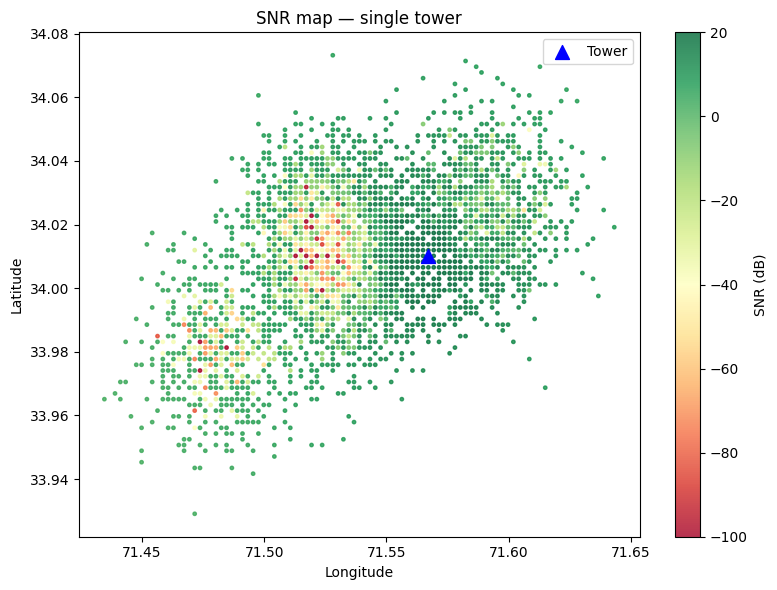

In [7]:
lats = grid.cells[:, 0]
lngs = grid.cells[:, 1]
snrs = result['snr_map']

plt.figure(figsize=(8, 6))
sc = plt.scatter(lngs, lats, c=snrs, cmap='RdYlGn', s=6,
                 vmin=-100, vmax=20, alpha=0.8)
plt.colorbar(sc, label='SNR (dB)')
plt.scatter([tower['lng']], [tower['lat']], marker='^', color='blue', s=100, zorder=5, label='Tower')
plt.title('SNR map — single tower')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.tight_layout()
plt.show()